In [555]:
################ Import necessary libraries

%pip install pyblp
%pip install statsmodels
%pip install linearmodels
%pip install stargazer

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS
from linearmodels import IV2SLS
from stargazer.stargazer import Stargazer
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [585]:
################ Import data
df = pd.read_csv('model_ready.csv')
supply_df = pd.read_csv('supply_ready.csv')
df = df.reset_index(drop=True)

# 将 supply_df 中的 road_fuel_IV 合并到 df
# 假设合并键为 province 和 year

df = df.merge(
    supply_df[['province', 'year', 'road_fuel_IV', 'num_models_in_market']],
    on=['province', 'year'],
    how='left'
)

# 计算 log(sjm), log(s0m), log(sj/g)
df['log_sjm'] = np.log(df['shares'])
df['log_s0m'] = np.log(1 - df.groupby('market_ids')['shares'].transform('sum'))
df['log_sj_g'] = np.log(df['shares'] / df.groupby(['market_ids', 'nesting_ids'])['shares'].transform('sum'))
df['log_charging_stock'] = np.log(df['charging_stations_stock'])

# Set range, log_charging_stock, log_charging_IV, and battery_capacity to 0 for non-EVs
df.loc[df['is_electric'] == 0, ['range', 'battery_capacity']] = 0

In [586]:
# Define list of IVs
iv_list = [
    'cost_shifter', 
    'product_set_size',
    'euclidean_range',
    'local_range',
    'euclidean_battery',
    'local_battery',
    'euclidean_power',
    'local_power',
    'road_fuel_IV',
    'num_models_in_market',
]

iv_str = ' + '.join(iv_list)

In [589]:
################ 2SLS model using custom instruments

# First stage for charging station: regress log_charging_stock on instrument variables
X = sm.add_constant(df['log_charging_IV'])
y = df['log_charging_stock']
first_stage = sm.OLS(y, X).fit()
df['log_charging_stock_hat'] = first_stage.predict(X)

# Define the formula for the IV2SLS model
formula = f'''
(log_sjm - log_s0m) ~ 0 + is_electric*log_charging_stock_hat + range + power + battery_capacity
    + [net_prices + log_sj_g ~ {iv_str}]
'''
# CAN HAVE HORSEPOWER = POWER / MASS #

iv_model = IV2SLS.from_formula(formula, data=df).fit(cov_type="clustered", clusters=df['market_ids'])

print(iv_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                log_sjm   R-squared:                      0.9823
Estimator:                    IV-2SLS   Adj. R-squared:                 0.9823
No. Observations:               33545   F-statistic:                 7.239e+04
Date:                Sat, Aug 02 2025   P-value (F-stat)                0.0000
Time:                        22:30:00   Distribution:                  chi2(8)
Cov. Estimator:             clustered                                         
                                                                              
                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
is_electric                           -15.658     0.6756   

In [559]:
# Output demand results as LaTeX table using Stargazer, only show selected coefficients
demand_stargazer = Stargazer([iv_model])
demand_stargazer.covariate_order(['net_prices', 'log_sj_g', 'is_electric:log_charging_stock_hat'])
demand_stargazer.rename_covariates({
    'net_prices': 'price',
    'log_sj_g': r'$\rho$',
    'is_electric:log_charging_stock_hat': r'$\beta^N$'
})
latex_demand = demand_stargazer.render_latex()

# Optionally, save to file
with open('GraphsTables/demand_model_result.tex', 'w', encoding='utf-8') as f:
    f.write(latex_demand)

In [560]:
################ Supply side model

# Create a time trend variable
supply_df['time_trend'] = supply_df['year'].astype(int) - supply_df['year'].astype(int).min() + 1

# Add time_trend
formula = 'log(charging_stations_stock) ~ [log(EV_stock) ~ road_fuel_IV + num_models_in_market + sales_weighted_avg_range] + sub_fix + sub_ope + C(province) + C(year)'

supply_model = IV2SLS.from_formula(formula, data=supply_df).fit()
print(supply_model.summary)

                               IV-2SLS Estimation Summary                               
Dep. Variable:     log(charging_stations_stock)   R-squared:                      0.9592
Estimator:                              IV-2SLS   Adj. R-squared:                 0.9463
No. Observations:                           155   F-statistic:                 7.039e+05
Date:                          Sat, Aug 02 2025   P-value (F-stat)                0.0000
Time:                                  16:57:09   Distribution:                 chi2(38)
Cov. Estimator:                          robust                                         
                                                                                        
                                      Parameter Estimates                                      
                             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------


In [561]:
# Export model summary as LaTeX
supply_stargazer = Stargazer([supply_model])
supply_stargazer.covariate_order(['sub_fix', 'sub_ope', 'log(EV_stock)'])
supply_stargazer.rename_covariates({
    'sub_fix': 'fixed subsidy',
    'sub_ope': 'operating subsidy',
    'log(EV_stock)': r'$\lambda_1$'
})
latex_supply = supply_stargazer.render_latex()

# Optionally, save to file
with open('GraphsTables/supply_model_result.tex', 'w', encoding='utf-8') as f:
    f.write(latex_supply)

In [562]:
# Save demand model results
with open('demand_model_results.pkl', 'wb') as f:
    pickle.dump(iv_model, f)

# Save supply model results
with open('charging_station_model_results.pkl', 'wb') as f:
    pickle.dump(supply_model, f)

In [563]:
# Export model data for counterfactual analysis
df.to_csv('demand_counterfactual.csv', index=False)
supply_df.to_csv('supply_counterfactual.csv', index=False)

In [564]:
def compute_nested_logit_elasticities(
    df,
    demand_par,
    price_col='net_prices',
    market_col='market_ids',
    model_col='model_id',
    nest_col='nesting_ids'
):
    """
    Compute own and cross price elasticities for each market using your equations 12, 14, 15.
    Returns:
        dict: {market_id: elasticity_matrix (DataFrame, index/columns=model_id)}
    """
    alpha = demand_par.params['net_prices']
    sigma = 0.6
    elasticity_matrices = {}

    # Compute within-nest shares for all rows
    df['nest_sum'] = df.groupby([market_col, nest_col])['shares'].transform('sum')
    df['within_nest_share'] = df['shares'] / df['nest_sum']

    unique_markets = df[market_col].unique()
    for market_id in unique_markets:
        df_mkt = df[df[market_col] == market_id].copy()
        n = len(df_mkt)
        elasticity = np.zeros((n, n))
        prices = df_mkt[price_col].values
        shares = df_mkt['shares'].values
        within_nest_shares = df_mkt['within_nest_share'].values
        nests = df_mkt[nest_col].values
        model_ids = df_mkt[model_col].values

        # Compute group shares for each product
        group_shares = df_mkt['nest_sum'].values

        for j in range(n):
            s_j = shares[j]
            s_jg = within_nest_shares[j]
            s_g = group_shares[j]
            for k in range(n):
                s_k = shares[k]
                if j == k:
                    # Own-price elasticity (Equation 12)
                    deriv = (1/(1-sigma)) * s_j * (1 - sigma*s_jg - (1-sigma)*s_j)
                elif nests[j] == nests[k]:
                    # Cross-price elasticity within the same group (Equation 14)
                    deriv = -s_j * s_k * (1 + (sigma/(1-sigma)) * (1/s_g))
                else:
                    # Cross-price elasticity across groups (Equation 15)
                    deriv = -s_j * s_k
                # Convert to price elasticity
                elasticity[j, k] = alpha * prices[k] * deriv / s_j

        elasticity_df = pd.DataFrame(elasticity, index=model_ids, columns=model_ids)
        elasticity_matrices[market_id] = elasticity_df

    return elasticity_matrices

In [565]:
# Demand model results
with open('demand_model_results.pkl', 'rb') as f:
     demand_param = pickle.load(f)

# Charging station model results
with open('charging_station_model_results.pkl', 'rb') as f:
     charging_param = pickle.load(f)

In [566]:
# Compute elasticities with network effects
elasticity_matrices = compute_nested_logit_elasticities(
    df,
    demand_param,
    price_col='net_prices',
    market_col='market_ids',
    model_col='model_id',
    nest_col='nesting_ids'
)

In [567]:
# Compute charging station semi-elasticities (γ_j)
def compute_gamma_dict(beta_N, df, nest_col='nesting_ids', market_col='market_ids', share_col='shares', sigma=None):
    """
    Compute charging station semi-elasticities (γ_j) for all products, returned as a dict by market.
    Returns:
        dict: {market_id: gamma vector for that market}
    """
    gamma_dict = {}
    for market_id in df[market_col].unique():
        market_df = df[df[market_col] == market_id].copy()
        market_df['nest_sum'] = market_df.groupby([market_col, nest_col])[share_col].transform('sum')
        market_df['within_nest_share'] = market_df[share_col] / market_df['nest_sum']
        if isinstance(sigma, dict):
            sigma_g = market_df[nest_col].map(sigma)
        else:
            sigma_g = sigma
        term = (1 / (1 - sigma_g)) * (1 - sigma_g * market_df['within_nest_share'] - (1 - sigma_g) * market_df[share_col])
        gamma = beta_N * market_df[share_col] * term
        gamma_dict[market_id] = gamma.values
    return gamma_dict

In [568]:
# Elasticity with network effects
def compute_total_derivatives(df, eta_dict, gamma_dict, v_2, is_ev_col='is_electric', market_col='market_ids'):
    """
    Compute total derivatives of market shares w.r.t. prices (with network effects).
    Args:
        df (pd.DataFrame): DataFrame with all markets.
        eta_dict (dict): {market_id: JxJ eta matrix for that market}.
        gamma_dict (dict): {market_id: gamma vector for that market}.
        v_2 (float): Sensitivity of charging stations to EV sales.
        is_ev_col (str): Column name for EV indicator.
        market_col (str): Column name for market IDs.
    Returns:
        dict: {market_id: JxJ matrix of total derivatives for each market}.
    """
    total_derivatives_dict = {}
    for market_id in df[market_col].unique():
        market_df = df[df[market_col] == market_id].reset_index(drop=True)
        eta = eta_dict[market_id]
        gamma = gamma_dict[market_id]
        is_ev = market_df[is_ev_col].values.astype(bool)
        shares = market_df['shares'].values
        J = len(gamma)
        total_derivatives = np.zeros((J, J))
        s_ev = np.sum(shares[is_ev])
        sum_gamma_ev = np.sum(gamma[is_ev])
        eta = np.asarray(eta)  
        for j in range(J):
            for k in range(J):
                if is_ev[j]:
                    feedback_term = 0
                    denom = s_ev - v_2 * sum_gamma_ev
                    if denom != 0:
                        feedback_term = v_2 * gamma[j] * np.sum(eta[is_ev, k]) / denom
                    total_derivatives[j, k] = eta[j, k] + feedback_term
                else:
                    total_derivatives[j, k] = eta[j, k]
        total_derivatives_dict[market_id] = total_derivatives
    return total_derivatives_dict

In [569]:
# Calculate gamma_dict for all markets
beta_N = demand_param.params['log_charging_stock_hat']
sigma = demand_param.params['log_sj_g']

gamma_dict = compute_gamma_dict(
    beta_N=beta_N,
    df=df,
    nest_col='nesting_ids',
    market_col='market_ids',
    share_col='shares',
    sigma=sigma
)

# Compute total derivatives using elasticity_matrices as eta_dict and gamma_dict as input
total_derivatives_dict = compute_total_derivatives(
    df=df,
    eta_dict=elasticity_matrices,
    gamma_dict=gamma_dict,
    v_2=charging_param.params['log(EV_stock)'], 
    is_ev_col='is_electric',
    market_col='market_ids'
)


In [595]:
# show all names of EV models in the sample market
sample_market = 'P01Y2019'
df[(df['market_ids'] == sample_market) & (df['is_electric'] == 1)]['model'].unique()


array(['Jingyi S50', 'Yudo π1', 'Yudo π3', 'Jiaji', 'Emgrand',
       'Emgrand GL', 'Emgrand GSe', 'Xingyue', 'Binyue', 'Audi A6L',
       'Audi Q2L', 'BMW 5 Series', 'BMW X1', 'Baojun E100', 'XPeng G3',
       'Sylphy', 'ORA iQ', 'JAC iEV6E', 'Volvo XC60', 'GAC NE EV',
       'Mondeo', 'Territory', 'Hongqi E-HS3', 'Denza', 'Roewe Ei5',
       'Roewe RX5 eMAX', 'NIO ES6', 'NIO ES8', 'Kia K3', 'Kia K5', 'Eado',
       'Changan CS75', 'Lynk & Co 01', 'Lynk & Co 03'], dtype=object)

In [596]:
# Generate sample elasticity table for selected EV models with 6 digits, dropping duplicates

sample_market = 'P01Y2019'
selected_models = [
    'Roewe Ei5', 'BMW X1', 'Audi A6L', 'Kia K5', 'Lynk & Co 03'
]

# Ensure only unique model names and present in the selected market
market_df = df[(df['market_ids'] == sample_market) & (df['is_electric'] == 1)]
available_models = [m for m in selected_models if m in market_df['model'].unique()]

elasticity_matrix_full = elasticity_matrices[sample_market]
model_names = df[df['market_ids'] == sample_market]['model'].values

# Set index and columns to model names
elasticity_matrix_full.index = model_names
elasticity_matrix_full.columns = model_names

# Create a mask for first occurrence of each model name
_, idx = np.unique(model_names, return_index=True)
unique_model_names = model_names[np.sort(idx)]

# Filter elasticity_matrix to only include first occurrence for each model name
elasticity_matrix = elasticity_matrix_full.loc[unique_model_names, unique_model_names]
sample_elasticity = elasticity_matrix.loc[available_models, available_models]
sample_total_deriv_df = pd.DataFrame(
    total_derivatives_dict[sample_market],
    index=elasticity_matrix.index,
    columns=elasticity_matrix.columns
).loc[available_models, available_models]

# Drop duplicate rows and columns by model name in sample_elasticity
sample_elasticity = sample_elasticity[~sample_elasticity.index.duplicated(keep='first')]
sample_elasticity = sample_elasticity.loc[:, ~sample_elasticity.columns.duplicated(keep='first')]

# Drop duplicate rows and columns by model name in sample_total_deriv_df
sample_total_deriv_df = sample_total_deriv_df[~sample_total_deriv_df.index.duplicated(keep='first')]
sample_total_deriv_df = sample_total_deriv_df.loc[:, ~sample_total_deriv_df.columns.duplicated(keep='first')]

def matrix_to_latex(matrix, caption):
    latex = "\\begin{table}[!htbp]\n\\centering\n"
    latex += "\\begin{tabular}{@{\\extracolsep{5pt}}l" + "c" * len(matrix.columns) + "}\n"
    latex += "\\\\[-1.8ex]\\hline\n\\\\hline \\\\[-1.8ex]\n"
    latex += "& " + " & ".join(matrix.columns) + " \\\\\n"
    latex += "\\hline \\\\[-1.8ex]\n"
    for idx, row in matrix.iterrows():
        latex += f"{idx} & " + " & ".join([f'{v:.6f}' for v in row]) + " \\\\\n"
    latex += "\\hline \\\\[-1.8ex]\n"
    latex += "\\end{tabular}\n"
    latex += f"\\caption{{{caption}}}\n"
    latex += "\\end{table}\n"
    return latex

latex_without_network = matrix_to_latex(sample_elasticity, "Elasticity matrix WITHOUT network effects (selected EV models)")
latex_with_network = matrix_to_latex(sample_total_deriv_df, "Elasticity matrix WITH network effects (selected EV models)")

with open('GraphsTables/sample_elasticity_selected_without_network.tex', 'w', encoding='utf-8') as f:
    f.write(latex_without_network)

with open('GraphsTables/sample_elasticity_selected_with_network.tex', 'w', encoding='utf-8') as f:
    f.write(latex_with_network)

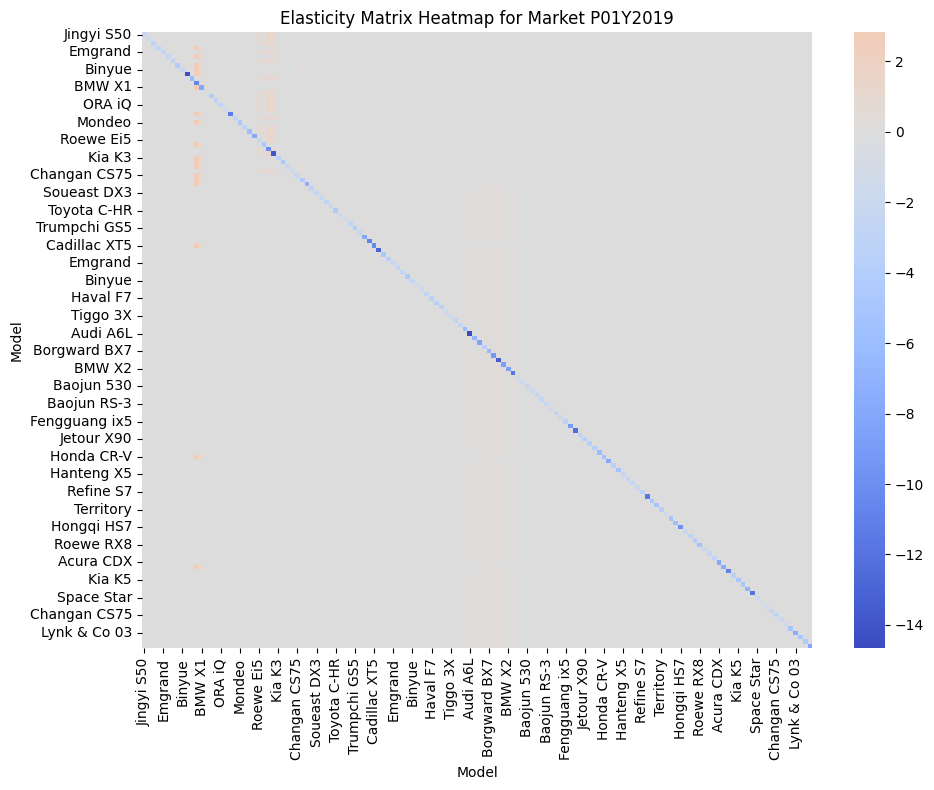

In [ ]:
# Pick a sample market
sample_market = list(elasticity_matrices.keys())[0]
sample_elasticity = elasticity_matrices[sample_market]

# Optionally, set model names as index/columns for better labels
model_names = df[df['market_ids'] == sample_market]['model'].values
sample_elasticity.index = model_names
sample_elasticity.columns = model_names

plt.figure(figsize=(10, 8))
sns.heatmap(sample_elasticity, cmap='coolwarm', center=0)
plt.title(f'Elasticity Matrix Heatmap for Market {sample_market}')
plt.xlabel('Model')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average own price elasticity for EV and non-EV

avg_own_price_elasticities_ev = {}
avg_own_price_elasticities_nonev = {}

for market_id, elasticity_df in elasticity_matrices.items():
    market_df = df[df['market_ids'] == market_id]
    is_ev = market_df['is_electric'].values
    own_elasticities = np.diag(elasticity_df)
    avg_own_price_elasticities_ev[market_id] = np.mean(own_elasticities[is_ev == 1])
    avg_own_price_elasticities_nonev[market_id] = np.mean(own_elasticities[is_ev == 0])

# Convert to DataFrame for summary
avg_own_elasticity_ev_df = pd.DataFrame.from_dict(avg_own_price_elasticities_ev, orient='index', columns=['EV'])
avg_own_elasticity_nonev_df = pd.DataFrame.from_dict(avg_own_price_elasticities_nonev, orient='index', columns=['Non-EV'])

print("Average own price elasticity for EV by market:")
print(avg_own_elasticity_ev_df)
print("\nAverage own price elasticity for Non-EV by market:")
print(avg_own_elasticity_nonev_df)

overall_avg_ev = avg_own_elasticity_ev_df['EV'].mean()
overall_avg_nonev = avg_own_elasticity_nonev_df['Non-EV'].mean()
print("\nOverall average own price elasticity for EV:", overall_avg_ev)
print("Overall average own price elasticity for Non-EV:", overall_avg_nonev)

Average own price elasticity for EV by market:
                EV
P01Y2019 -4.858376
P02Y2019 -5.004727
P03Y2019 -5.008505
P04Y2019 -4.849150
P05Y2019 -5.859598
...            ...
P27Y2023 -6.439822
P28Y2023 -6.322224
P29Y2023 -6.329571
P30Y2023 -6.866838
P31Y2023 -6.502658

[155 rows x 1 columns]

Average own price elasticity for Non-EV by market:
            Non-EV
P01Y2019 -4.740263
P02Y2019 -4.646852
P03Y2019 -4.647493
P04Y2019 -4.692312
P05Y2019 -4.677147
...            ...
P27Y2023 -5.353004
P28Y2023 -5.400438
P29Y2023 -5.345402
P30Y2023 -5.566061
P31Y2023 -5.369818

[155 rows x 1 columns]

Overall average own price elasticity for EV: -5.50298749116152
Overall average own price elasticity for Non-EV: -5.024652864737165
